# Health Assistance through Fine-Tuned LoRA-Based Language Models, with Explainable AI (XAI) Analysis

<link rel="stylesheet" href="/site-assets/css/gemma.css">
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Google+Symbols:opsz,wght,FILL,GRAD@20..48,100..700,0..1,-50..200" />

## Overview

Gemma is a family of lightweight, state-of-the-art open models developed using the same research and technology behind the Gemini models.

Large Language Models (LLMs) like Gemma excel at various natural language processing (NLP) tasks. These models undergo pre-training on vast text corpora in a self-supervised manner, allowing them to learn general knowledge, such as statistical word relationships. They can then be fine-tuned with domain-specific data to perform specialized tasks like sentiment analysis.

Since LLMs contain billions of parameters, full fine-tuning is often unnecessary, as fine-tuning datasets are significantly smaller than pre-training datasets.

Low-Rank Adaptation (LoRA) is an efficient fine-tuning technique that minimizes the number of trainable parameters by freezing the model’s original weights and integrating a small set of additional weights. This approach accelerates training, reduces memory usage, and produces smaller model weights (a few hundred megabytes), all while preserving output quality.

This notebook also supports the thesis *"Enhancing Fairness through AI in Healthcare: Detection and Mitigation of Bias using Explainable AI (XAI)."* Beyond fine-tuning, it adds an Explainable AI (XAI) analysis pass -- SHAP, LIME, and a demographic-framing counterfactual probe -- that compares the **base** (pre-LoRA) and **LoRA fine-tuned** Gemma models, so the effect of fine-tuning on the model's reasoning, and its sensitivity to demographic framing, can be inspected directly.

**This version runs entirely locally** (no Kaggle Notebooks environment required): it downloads `google/gemma-3-1b-it` in Transformers/safetensors format from **Kaggle Model Hub** via `kagglehub` (just a Kaggle account + API token, no Hugging Face account needed), and fine-tunes it with LoRA using PyTorch, `transformers`, and `peft` instead of Kaggle's Keras/JAX stack.

## Setup

### Get access to Gemma

This notebook downloads the model from **Kaggle Model Hub** (not Hugging Face) via `kagglehub`, using your existing Kaggle account. Before running it:

* Go to the [Gemma 3 model page on Kaggle](https://www.kaggle.com/models/google/gemma-3) while signed in, and accept the license/consent terms (one-time, tied to your Kaggle account). This step is required even with a valid API token -- skipping it produces a 403 "permission" error that looks like an auth problem but isn't.
* Create a Kaggle API token from your account settings (Account -> API -> Create New Token).

### Runtime

This runs on whatever hardware is available: an NVIDIA GPU if `torch.cuda.is_available()` (int8-quantized via `bitsandbytes`), otherwise CPU (unquantized float32 -- much slower, but still functional for a 1B-parameter model). Note: on CPU this deliberately uses float32, not bfloat16 -- most consumer/laptop CPUs (including 12th-gen-and-earlier Intel) have no native BF16 vector instructions, so bf16 matmul on CPU silently falls back to a much slower path (measured ~90x slower than fp32 on a 12th-gen Intel chip). The GPU/CPU check happens automatically further down; there's nothing to configure here.

### Kaggle authentication

Set your credentials as environment variables before launching the notebook -- either the classic pair:

```
export KAGGLE_USERNAME=your_username
export KAGGLE_KEY=your_key
```

or the newer single token:

```
export KAGGLE_API_TOKEN=KGAT_...
```

`kagglehub` reads these automatically; there's no explicit login call needed.

In [1]:
import os

# kagglehub reads KAGGLE_USERNAME/KAGGLE_KEY or KAGGLE_API_TOKEN from the
# environment automatically -- this just confirms one of them is set before
# we try to download anything.
has_creds = bool(
    os.environ.get("KAGGLE_API_TOKEN")
    or (os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"))
)
assert has_creds, (
    "Set KAGGLE_API_TOKEN, or KAGGLE_USERNAME + KAGGLE_KEY, as environment "
    "variables before running this notebook."
)
print("Kaggle credentials found in environment.")

Kaggle credentials found in environment.


### Install dependencies

Install PyTorch, Transformers, PEFT, and other dependencies. If you already ran `pip install -r requirements.txt` in your venv, this cell is a no-op re-check.

In [2]:
!pip install -q -U torch transformers accelerate peft bitsandbytes kagglehub


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Import packages

Import PyTorch and Transformers.

In [3]:
import torch
import transformers
import peft

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

/home/olabs/lors/lora/lora/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [4]:
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no CUDA GPU detected -- running on CPU will be slow.")

torch: 2.13.0+cu130
transformers: 5.14.1
peft: 0.19.1


## Load Dataset

This uses the `newdata.jsonl` file sitting next to this notebook (no Kaggle Data panel / dataset upload needed). Update `DATASET_PATH` below if you keep it somewhere else.

In [5]:
DATASET_PATH = "newdata.jsonl"

assert os.path.isfile(DATASET_PATH), f"Dataset not found at {DATASET_PATH}"
print("Found dataset:", os.path.abspath(DATASET_PATH))

Found dataset: /home/olabs/lors/lora/lora/newdata.jsonl


Preprocess the data. This tutorial uses a subset of 1500 training examples to execute the notebook faster. Consider using more training data for higher quality fine-tuning.

In [6]:
import pandas as pd
import json

# JSON Lines (.jsonl): one JSON value per line. Each line may itself be a
# single {"prompt": ..., "response": ...} record or a JSON array of such
# records -- this handles both, which plain `pd.read_json(path)` does not
# (that call errors with "Trailing data" on multi-line JSON).
records = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        records.extend(obj if isinstance(obj, list) else [obj])

df = pd.DataFrame(records)
df

,prompt,response
0,"Tell me about CORN SNACK, CHEESE FLAVOURED (SN...","CORN SNACK, CHEESE FLAVOURED (SNEK JAGUNG BERP..."
1,"Is RICE, COOKED (NASI) suitable for a keto diet?","RICE, COOKED (NASI) is a food item in the grou..."
2,"What's in RICE, COOKED (NASI)?","RICE, COOKED (NASI) is a food item in the grou..."
3,How can I cultivate a positive mindset and pra...,1. Start your day with affirmations or a grati...
4,instruction,output
...,...,...
725,Is MILK CEREAL (RICE) FOR INFANTS (BIJIRIN BER...,MILK CEREAL (RICE) FOR INFANTS (BIJIRIN BERSUS...
726,"What are the nutritional contents of RICE, BRO...","RICE, BROKEN (BERAS HANCUR) ORYZA SATIVA is a ..."
727,"Can someone with a nut allergy eat NOODLE, RIC...","NOODLE, RICE (KUIH-TEOW) is a food item in the..."
728,What are some practical tips for maintaining g...,1. Brush at least twice a day and floss at lea...


In [7]:
# Shared instruction/response template, reused for training, generation,
# and the XAI cells below so every prompt fed to the model is formatted
# identically.
PROMPT_TEMPLATE = "Instruction:\n{prompt}\n\nResponse:\n{response}"

print(f"{len(records)} records loaded.")

730 records loaded.


In [8]:
# Show a sample formatted example
print(PROMPT_TEMPLATE.format(prompt=records[0]["prompt"], response=records[0]["response"]))

Instruction:
Tell me about CORN SNACK, CHEESE FLAVOURED (SNEK JAGUNG BERPERISA KEJU).

Response:
CORN SNACK, CHEESE FLAVOURED (SNEK JAGUNG BERPERISA KEJU) is a food item in the group 'cereals and cereal products'. It has a portion size of 100 grams, containing 3.1 grams of water, 499.0 kcal of energy, 9.3 grams of protein, 24.0 grams of fat, 61.4 grams of carbohydrates, 0.0 grams of fiber, and 483 mg of sodium.


## Load Model

Downloads `google/gemma-3-1b-it` -- a 1 billion parameter, instruction-tuned, text-only Gemma 3 model -- from **Kaggle Model Hub** via `kagglehub` (Transformers/safetensors format), then loads it with `transformers.AutoModelForCausalLM`. On a CUDA GPU it loads directly in int8 (via `bitsandbytes`, QLoRA-style: frozen quantized base + small trainable LoRA adapters); on CPU it falls back to an unquantized **float32** load -- not bfloat16 -- since most CPUs (this machine included) lack native BF16 vector instructions and silently run bf16 matmul through a scalar fallback path roughly two orders of magnitude slower than fp32.

In [9]:
# Sanity-check before downloading/loading the model. If this prints "cpu",
# everything below will be correct but very slow -- see the driver
# troubleshooting notes if you expected a GPU here.
print("torch.cuda.is_available():", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi --query-gpu=name,memory.total,memory.used,memory.free --format=csv
else:
    print("WARNING: no CUDA GPU detected. Loading unquantized on CPU.")

torch.cuda.is_available(): False


In [10]:
import kagglehub
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_HANDLE = "google/gemma-3/transformers/gemma-3-1b-it"
QUANTIZED = DEVICE == "cuda"

# Downloads (and caches) the model from Kaggle Model Hub in
# Transformers/safetensors format -- no Hugging Face account needed.
MODEL_PATH = kagglehub.model_download(MODEL_HANDLE)
print("Model files at:", MODEL_PATH)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if QUANTIZED:
    gemma_lm = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        quantization_config=BitsAndBytesConfig(load_in_8bit=True),
        device_map="auto",
    )
else:
    # float32, not bfloat16: most CPUs (this one included -- 12th-gen Intel,
    # no AVX512-BF16) lack native BF16 vector support, so bf16 matmul on CPU
    # silently falls back to a much slower path. Measured on this machine:
    # ~90x slower than fp32 for a same-shape matmul. fp32 is the fast CPU
    # default here even though it doubles memory vs bf16.
    gemma_lm = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH, torch_dtype=torch.float32,
    ).to(DEVICE)

print(f"Loaded {MODEL_HANDLE} ({'int8 quantized' if QUANTIZED else 'float32, unquantized'}) on {DEVICE}")
print(f"Memory footprint: {gemma_lm.get_memory_footprint() / 1e9:.2f} GB")

Model files at: /home/olabs/.cache/kagglehub/models/google/gemma-3/transformers/gemma-3-1b-it/1


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!



Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]


Loading weights:  69%|██████▉   | 235/340 [00:00<00:00, 2323.87it/s]


Loading weights: 100%|██████████| 340/340 [00:00<00:00, 2407.79it/s]

Loaded google/gemma-3/transformers/gemma-3-1b-it (float32, unquantized) on cpu
Memory footprint: 4.00 GB


`kagglehub.model_download` downloads (and caches locally) the model files from Kaggle Model Hub; `from_pretrained` then instantiates the model architecture and weights from that local path. `"google/gemma-3/transformers/gemma-3-1b-it"` is the 1 billion parameter, instruction-tuned Gemma 3 model in Transformers/safetensors format.

## Quantization

Unlike Keras 3's `model.quantize(mode)` (a separate step run *before* `enable_lora()`), `bitsandbytes` quantizes at load time -- that already happened in the `from_pretrained(..., quantization_config=...)` call above when a GPU is available. `peft`'s LoRA adapters are added on top of that frozen int8 base (the QLoRA pattern), same as the original notebook.

At 1B parameters this model is already light, so quantization here is more of a memory safety margin than a strict requirement -- but it's essentially free on GPU, so we keep it.

In [11]:
# Confirm what actually got loaded (quantization happened above, at
# from_pretrained time).
print("Quantized (int8):", QUANTIZED)
print(gemma_lm.config)

Quantized (int8): False
Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "float32",
  "eos_token_id": 1,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 1152,
  "initializer_range": 0.02,
  "intermediate_size": 6912,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention

## Explainable AI (XAI) Setup: SHAP

Per the thesis *"Enhancing Fairness through AI in Healthcare: Detection and Mitigation of Bias using Explainable AI (XAI),"* this notebook extends the LoRA fine-tuning pipeline with explainability techniques so the **base** (pre-LoRA) and **LoRA fine-tuned** Gemma models can be compared directly:

- **SHAP (Shapley Additive Explanations)** — measures how much each word of the prompt contributes to the model's confidence in the response it generates.
- **LIME** and a **Counterfactual Explanation** probe are added further down, after fine-tuning, to cross-check SHAP's word-importance ranking and to test whether the model's advice changes inappropriately when the same instruction is reframed with different demographic details (age, gender, location).

Equalized Odds / Demographic Parity require a structured dataset with per-record demographic and outcome labels, which this instruction/response chatbot dataset does not have; those metrics belong to a companion bias-auditing module against structured clinical data.

We capture the explainability snapshot for the **base** model now, before LoRA is enabled below, so it reflects the pretrained model's behavior.

**Performance note**: `MAX_LENGTH` is set to 256 tokens below (rather than a much larger default) so every SHAP/LIME forward pass stays fast. The SHAP/LIME scoring function also batches all masked variants into a single forward pass per call instead of looping one-at-a-time, and `max_evals`/`num_samples` are trimmed to a level appropriate for a ~15-20 word instruction rather than a generic default.

In [12]:
# Set this now (not just later, right before training) so every XAI forward
# pass below -- base snapshot, LoRA snapshot, LIME, counterfactual probe --
# also benefits from the smaller sequence length instead of padding to the
# tokenizer's much larger default.
MAX_LENGTH = 256

In [13]:
!pip install -q shap


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [14]:
import numpy as np
import shap
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Evaluation prompt reused for both the base and the LoRA fine-tuned model,
# so their explanations are directly comparable.
EVAL_INSTRUCTION = (
    "In Kathmandu there is huge air pollution. What should I do to be safe "
    "from the pollution?"
)
EVAL_PROMPT = PROMPT_TEMPLATE.format(prompt=EVAL_INSTRUCTION, response="")


def generate_response(model, prompt, max_new_tokens=256):
    """Generate text and return only the newly generated continuation."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return full_text[len(prompt):].strip()


def _response_score_fn(model, response):
    """Builds a SHAP/LIME scoring function.

    Given masked variants of the instruction, returns how confident `model`
    is in producing `response` (the mean log-probability it assigns to that
    response's tokens). A higher score means that instruction variant makes
    the model more confident in the response it actually generated.

    All `instruction_variants` passed in a single call are tokenized and run
    through the model as one padded batch, rather than one-by-one in a
    Python loop -- SHAP/LIME can call this with dozens of variants per step,
    and batching turns that into a single forward pass instead of dozens of
    separate ones.
    """
    response_len = len(tokenizer(response, add_special_tokens=False)["input_ids"])

    def score(instruction_variants):
        full_texts = [
            PROMPT_TEMPLATE.format(prompt=instruction, response="") + response
            for instruction in instruction_variants
        ]
        encoded = tokenizer(
            full_texts, return_tensors="pt", padding=True, truncation=True,
            max_length=MAX_LENGTH,
        ).to(model.device)

        with torch.no_grad():
            logits = model(**encoded).logits

        # Shift for next-token prediction (HF's internal convention when
        # `labels` is passed to the model -- we replicate it manually here
        # since we need per-token losses, not just the aggregate).
        shift_logits = logits[:, :-1, :]
        shift_targets = encoded["input_ids"][:, 1:]
        shift_mask = encoded["attention_mask"][:, 1:].bool()

        per_token_loss = F.cross_entropy(
            shift_logits.reshape(-1, shift_logits.size(-1)).float(),
            shift_targets.reshape(-1),
            reduction="none",
        ).reshape(shift_targets.shape)

        losses = per_token_loss.cpu().numpy()
        mask = shift_mask.cpu().numpy()

        # Only the loss over the response tokens (the tail of each
        # sequence's real, non-padding tokens) matters for "how confident is
        # the model".
        scores = np.zeros(len(instruction_variants))
        for i in range(len(instruction_variants)):
            valid_idx = np.nonzero(mask[i])[0]
            tail_idx = valid_idx[-min(response_len, len(valid_idx)):]
            if len(tail_idx) == 0:
                continue
            scores[i] = -losses[i, tail_idx].mean()
        return scores

    return score


def shap_word_importance(model, instruction, response, max_evals=80):
    """Per-word SHAP values: how much each word of `instruction` contributes
    to the model generating `response`.

    `max_evals=80` is trimmed down from SHAP's much larger defaults -- for a
    ~15-20 word instruction, that's still comfortably above the ~2N+1
    evaluations permutation SHAP needs as a floor, while cutting runtime
    substantially versus evaluating 150+ masked variants.
    """
    masker = shap.maskers.Text(r"\W+")
    score_fn = _response_score_fn(model, response)
    explainer = shap.Explainer(score_fn, masker, algorithm="permutation")
    return explainer([instruction], max_evals=max_evals)

Base model response:
 Okay, let's discuss how to protect yourself from the air pollution in Kathmandu. Here's a breakdown of what you can do, categorized for different levels of effort and resources:

**1. Immediate Actions (Easy & Quick - 5-15 minutes):**

* **Stay Indoors:** This is the most important thing.  Avoid going outside during peak pollution times (usually morning and evening).
* **Close Windows and Doors:** Seal any cracks or gaps around windows and doors to prevent pollutants from entering.
* **Turn on Fans:**  Fans can help circulate the air and reduce the concentration of pollutants.
* **Avoid Peak Times:** If possible, postpone outdoor activities to the early morning or late evening when the pollution is typically lower.

**2. Short-Term Strategies (15-60 minutes):**

* **Wear a Mask:** A well-fitting N95 or KN95 mask can significantly reduce your exposure to particulate matter.  (Note:  Ensure the mask fits properly to be effective.)
* **Stay Hydrated:** Drink plenty o


PermutationExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]


PermutationExplainer explainer: 2it [01:26, 86.72s/it]               

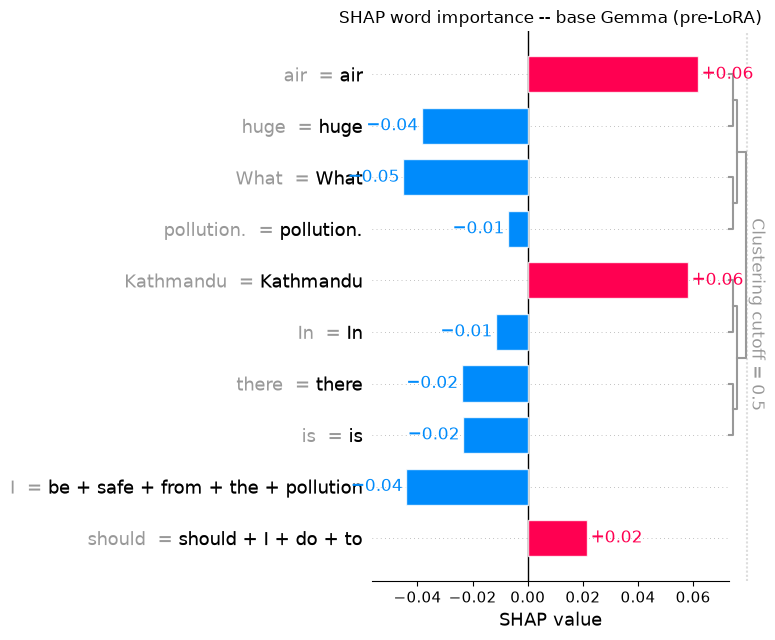

In [15]:
# Base model (pre-LoRA) explainability snapshot.
base_response = generate_response(gemma_lm, EVAL_PROMPT)
print("Base model response:\n", base_response)

base_shap = shap_word_importance(gemma_lm, EVAL_INSTRUCTION, base_response)
shap.plots.bar(base_shap[0], show=False)
plt.title("SHAP word importance -- base Gemma (pre-LoRA)")
plt.tight_layout()
plt.show()

## LoRA Fine-tuning

To enhance the model's responses, fine-tune it with Low Rank Adaptation (LoRA) using the "health assistance dataset for Kathmandu" dataset, via the `peft` library.

The LoRA rank determines the size of the trainable matrices added to the original LLM weights, influencing both the precision and flexibility of fine-tuning.

A higher rank allows for more detailed adjustments but increases the number of trainable parameters.
A lower rank reduces computational overhead but may limit adaptation precision.
This tutorial uses a LoRA rank of 4. In practice, start with a smaller rank (e.g., 4, 8, or 16) for efficient experimentation. Train and evaluate the model's performance, then gradually increase the rank if further improvements are needed.

In [16]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Casts layernorms to fp32, enables input-gradient tracking on the frozen
# int8 base, etc. -- required prep before adding LoRA adapters on top of a
# bitsandbytes-quantized model. No-op (returns model unchanged) on CPU.
if QUANTIZED:
    gemma_lm = prepare_model_for_kbit_training(gemma_lm)

lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM",
)
gemma_lm = get_peft_model(gemma_lm, lora_config)
gemma_lm.print_trainable_parameters()

/home/olabs/lors/lora/lora/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1112: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


trainable params: 745,472 || all params: 1,000,631,424 || trainable%: 0.0745


Note that enabling LoRA reduces the number of trainable parameters significantly compared to full fine-tuning of all 1B parameters -- the exact trainable-parameter count printed above (from `print_trainable_parameters()`).

In [17]:
import time
from functools import partial
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW


class PromptResponseDataset(Dataset):
    """Tokenizes each (prompt, response) pair and masks the prompt tokens
    with -100 so the loss is only computed over the response tokens, not
    the "Instruction:\n...\n\nResponse:\n" boilerplate -- a better
    training signal than scoring the whole joined string.
    """

    def __init__(self, records, max_length=MAX_LENGTH):
        self.records = records
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        prompt_text = PROMPT_TEMPLATE.format(prompt=record["prompt"], response="")
        full_text = prompt_text + record["response"] + tokenizer.eos_token

        prompt_ids = tokenizer(prompt_text, add_special_tokens=True)["input_ids"]
        full_ids = tokenizer(full_text, add_special_tokens=True)["input_ids"]
        full_ids = full_ids[: self.max_length]

        labels = list(full_ids)
        prompt_len = min(len(prompt_ids), len(full_ids))
        for i in range(prompt_len):
            labels[i] = -100

        return {
            "input_ids": torch.tensor(full_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


def collate_fn(batch, pad_token_id):
    max_len = max(len(item["input_ids"]) for item in batch)
    input_ids = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)
    labels = torch.full((len(batch), max_len), -100, dtype=torch.long)
    attention_mask = torch.zeros((len(batch), max_len), dtype=torch.long)
    for i, item in enumerate(batch):
        n = len(item["input_ids"])
        input_ids[i, :n] = item["input_ids"]
        labels[i, :n] = item["labels"]
        attention_mask[i, :n] = 1
    return {"input_ids": input_ids, "labels": labels, "attention_mask": attention_mask}


# batch_size: with batch_size=1 and ~1500 examples x 2 epochs, that's ~3000
# individual training steps -- each pays full CPU-side tokenization +
# Python/dispatch overhead for a single example, while the actual compute
# burst per step is tiny. Raising batch_size lets the GPU do meaningful
# parallel work per step and cuts step count proportionally. Lower this if
# you hit an out-of-memory error.
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 5e-5

# Plain-file progress log (in addition to the print()s below) so training
# progress can be tailed live from outside the notebook/kernel process,
# independent of when Jupyter flushes cell output.
PROGRESS_LOG = "/tmp/claude-1000/-home-olabs-lors/8e47de4b-2aa5-4770-9bee-d62f541e8ec5/scratchpad/training_progress.log"

def log_progress(msg):
    print(msg, flush=True)
    with open(PROGRESS_LOG, "a") as f:
        f.write(msg + "\n")

train_dataset = PromptResponseDataset(records)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=partial(collate_fn, pad_token_id=tokenizer.pad_token_id),
)

# AdamW is a common optimizer for transformer models. Only LoRA adapter
# params require grad, so this only trains those.
trainable_params = [p for p in gemma_lm.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=0.01)

steps_per_epoch = len(train_loader)
history = {"loss": [], "sparse_categorical_accuracy": []}
gemma_lm.train()
run_start = time.time()
open(PROGRESS_LOG, "w").close()
log_progress(f"Training start: {EPOCHS} epochs x {steps_per_epoch} steps/epoch = {EPOCHS * steps_per_epoch} total steps")

for epoch in range(EPOCHS):
    epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0
    epoch_start = time.time()
    for step, batch in enumerate(train_loader, 1):
        batch = {k: v.to(gemma_lm.device) for k, v in batch.items()}
        outputs = gemma_lm(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch["input_ids"].size(0)
        with torch.no_grad():
            preds = outputs.logits[:, :-1, :].argmax(dim=-1)
            targets = batch["labels"][:, 1:]
            mask = targets != -100
            epoch_correct += (preds[mask] == targets[mask]).sum().item()
            epoch_total += mask.sum().item()

        if step == 1 or step % 5 == 0 or step == steps_per_epoch:
            elapsed = time.time() - epoch_start
            per_step = elapsed / step
            remaining_steps = (EPOCHS - epoch - 1) * steps_per_epoch + (steps_per_epoch - step)
            eta_min = remaining_steps * per_step / 60
            log_progress(
                f"  epoch {epoch + 1}/{EPOCHS} step {step}/{steps_per_epoch} -- "
                f"{per_step:.1f}s/step -- elapsed {elapsed / 60:.1f}min -- ETA {eta_min:.1f}min"
            )

    epoch_loss /= len(train_dataset)
    epoch_acc = epoch_correct / max(epoch_total, 1)
    history["loss"].append(epoch_loss)
    history["sparse_categorical_accuracy"].append(epoch_acc)
    log_progress(
        f"Epoch {epoch + 1}/{EPOCHS} done -- loss: {epoch_loss:.4f} -- "
        f"accuracy: {epoch_acc:.4f} -- time: {(time.time() - epoch_start) / 60:.1f}min"
    )

log_progress(f"Total training time: {(time.time() - run_start) / 60:.1f}min")
gemma_lm.eval()

Training start: 5 epochs x 46 steps/epoch = 230 total steps


  epoch 1/5 step 1/46 -- 24.3s/step -- elapsed 0.4min -- ETA 92.7min


  epoch 1/5 step 5/46 -- 24.7s/step -- elapsed 2.1min -- ETA 92.7min


  epoch 1/5 step 10/46 -- 25.6s/step -- elapsed 4.3min -- ETA 93.8min


  epoch 1/5 step 15/46 -- 25.7s/step -- elapsed 6.4min -- ETA 92.1min


...

  epoch 5/5 step 45/46 -- 26.7s/step -- elapsed 20.0min -- ETA 0.4min


  epoch 5/5 step 46/46 -- 26.5s/step -- elapsed 20.3min -- ETA 0.0min


Epoch 5/5 done -- loss: 0.5406 -- accuracy: 0.8443 -- time: 20.3min


Total training time: 98.9min


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma3ForCausalLM(
      (model): Gemma3TextModel(
        (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma3DecoderLayer(
            (self_attn): Gemma3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1152, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1152, out_features=4, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=4, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              

In [18]:
# Save the LoRA adapter (a few hundred MB, not the full base model) to a
# local output directory.
my_model_name = "my_gemma3_1b_pt1"
gemma_lm.save_pretrained(f"./{my_model_name}")
tokenizer.save_pretrained(f"./{my_model_name}")
print(f"Saved LoRA adapter to ./{my_model_name}")

Saved LoRA adapter to ./my_gemma3_1b_pt1


### Note on mixed precision fine-tuning on NVIDIA GPUs

For fine-tuning, full precision is recommended. However, on NVIDIA GPUs, wrapping the forward/backward pass in `torch.autocast(device_type="cuda", dtype=torch.bfloat16)` can accelerate training with minimal impact on quality. This notebook doesn't enable it by default to keep the training loop simple, but it's a straightforward addition if you want the speedup.

Keep in mind that mixed precision requires more memory, making it beneficial primarily for larger GPUs.

For inference on a GPU, loading in half-precision (`torch_dtype=torch.bfloat16`) saves memory. On CPU, this notebook intentionally uses float32 instead -- see the note in the "Load Model" section above on why bf16 is much slower on CPUs without native BF16 support.

### Prompt

In [19]:
prompt = PROMPT_TEMPLATE.format(
    prompt="In Kathmandu there is huge air pollution. What should I do to be safe from the pollution?",
    response="",
)
# prompt="I have high blood pressure. Which hospital is better in kathmandu to checkup?"
lora_full_output = prompt + generate_response(gemma_lm, prompt)
print(lora_full_output)

Instruction:
In Kathmandu there is huge air pollution. What should I do to be safe from the pollution?

Response:
1. Stay indoors: If possible, stay indoors and avoid outdoor activities.
2. Use a mask: Wear a mask to filter the air.
3. Avoid outdoor activities: Avoid going outside, especially during peak pollution times.
4. Stay hydrated: Drink plenty of water to stay hydrated.
5. Avoid smoking: Avoid smoking to reduce exposure to harmful chemicals.
6. Avoid strenuous activity: Avoid strenuous activity to reduce exposure to harmful chemicals.
7. Stay informed: Stay informed about the air quality levels in your area.
8. Take precautions: Take precautions to protect yourself from the pollution.


## Explainable AI (XAI) Analysis: Base vs. LoRA-Tuned Comparison

Using the same evaluation prompt and the same `shap_word_importance` helper defined above, we now snapshot the **LoRA fine-tuned** model and compare it against the **base** snapshot captured before fine-tuning.

LoRA fine-tuned response:
 1. Stay indoors: If possible, stay indoors and avoid outdoor activities.
2. Use a mask: Wear a mask to filter the air.
3. Avoid outdoor activities: Avoid going outside, especially during peak pollution times.
4. Stay hydrated: Drink plenty of water to stay hydrated.
5. Avoid smoking: Avoid smoking to reduce exposure to harmful chemicals.
6. Avoid strenuous activity: Avoid strenuous activity to reduce exposure to harmful chemicals.
7. Stay informed: Stay informed about the air quality levels in your area.
8. Take precautions: Take precautions to protect yourself from the pollution.



PermutationExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]


PermutationExplainer explainer: 2it [00:55, 55.12s/it]               

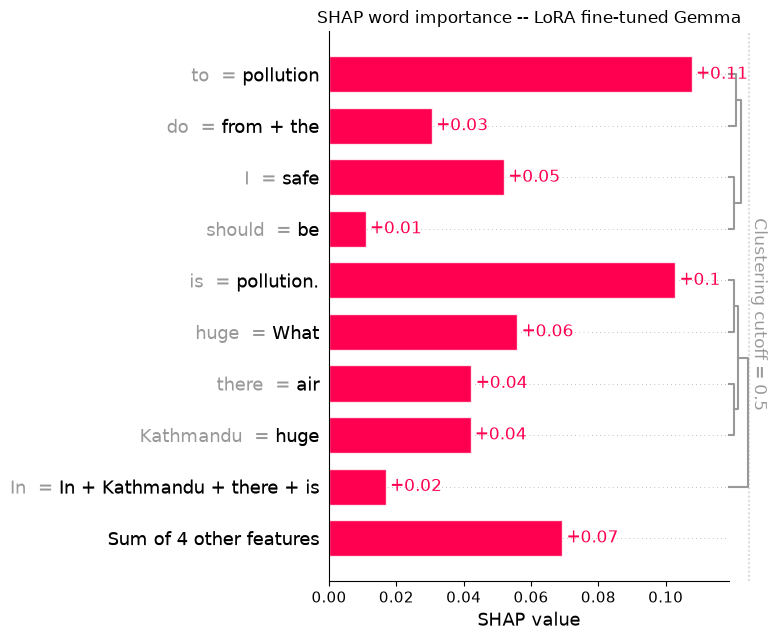

In [20]:
lora_response = lora_full_output[len(prompt):].strip()
print("LoRA fine-tuned response:\n", lora_response)

lora_shap = shap_word_importance(gemma_lm, EVAL_INSTRUCTION, lora_response)
shap.plots.bar(lora_shap[0], show=False)
plt.title("SHAP word importance -- LoRA fine-tuned Gemma")
plt.tight_layout()
plt.show()

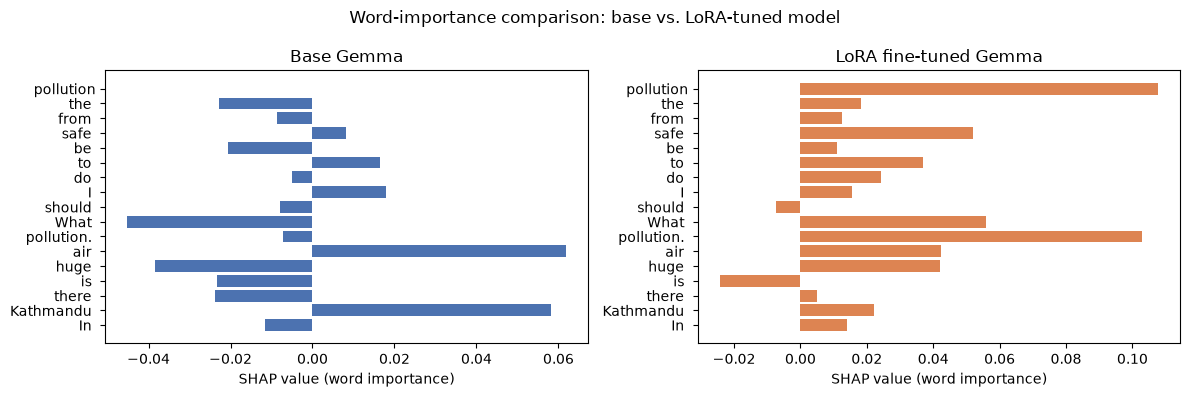

In [21]:
# Side-by-side word-importance comparison: base vs. LoRA-tuned model.
base_words, base_vals = list(base_shap[0].data), np.array(base_shap[0].values)
lora_words, lora_vals = list(lora_shap[0].data), np.array(lora_shap[0].values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
axes[0].barh(base_words, base_vals, color="#4C72B0")
axes[0].set_title("Base Gemma")
axes[1].barh(lora_words, lora_vals, color="#DD8452")
axes[1].set_title("LoRA fine-tuned Gemma")
for ax in axes:
    ax.set_xlabel("SHAP value (word importance)")
plt.suptitle("Word-importance comparison: base vs. LoRA-tuned model")
plt.tight_layout()
plt.show()

## LIME Explanation: Cross-Checking SHAP

LIME (Local Interpretable Model-Agnostic Explanations) fits a local linear surrogate around the instance being explained. `LimeTextExplainer` is built for classifiers, so we reuse the same `_response_score_fn` confidence score as SHAP and squash it into a pseudo-probability with a sigmoid, treating "the model is confident in its response" as the positive class. This lets us compare LIME's word-importance ranking against SHAP's for the same instruction/response pairs -- the consistency (or disagreement) between the two is itself a useful signal about how trustworthy either explanation is.

In [ ]:
!pip install --upgrade pip
!pip install -q lime

  DEPRECATION: lime is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


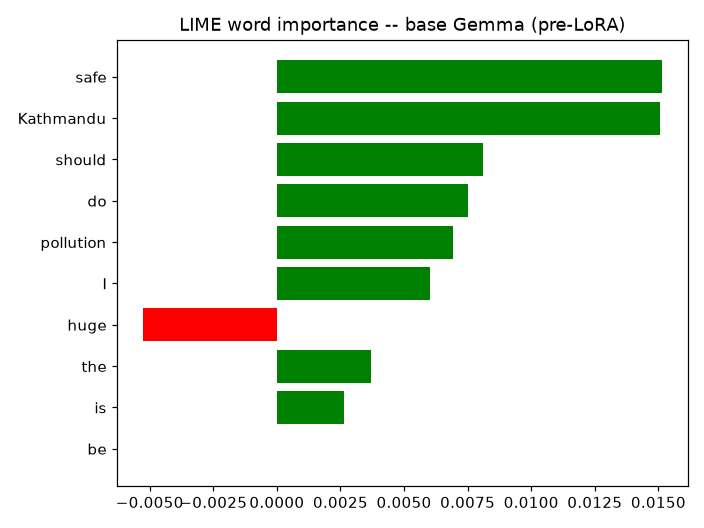

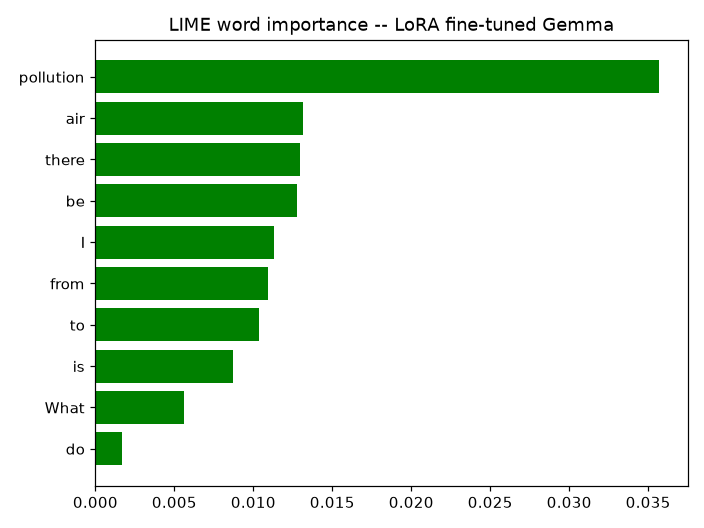

In [24]:
from lime.lime_text import LimeTextExplainer


def lime_word_importance(model, instruction, response, num_features=10, num_samples=100):
    """LIME word-importance explanation for the same (instruction, response)
    pair used by `shap_word_importance`.

    `LimeTextExplainer` expects a classifier returning (num_samples, num_classes)
    probabilities, so we wrap the scalar confidence score from
    `_response_score_fn` into a 2-class [not-confident, confident] probability
    via a sigmoid, and explain the "confident" class (label=1).

    `num_samples=100` (down from LIME's default of 5000) is enough for a
    ~15-20 word instruction and keeps this in line with `max_evals` above --
    `_response_score_fn` batches all of these into a single forward pass
    regardless, so this mainly controls how many masked variants LIME's
    local linear model gets fit on.
    """
    score_fn = _response_score_fn(model, response)

    def predict_fn(texts):
        scores = np.asarray(score_fn(list(texts)))
        probs = 1.0 / (1.0 + np.exp(-scores))
        return np.stack([1.0 - probs, probs], axis=1)

    explainer = LimeTextExplainer(class_names=["not confident", "confident"])
    return explainer.explain_instance(
        instruction, predict_fn, labels=(1,),
        num_features=num_features, num_samples=num_samples,
    )


base_lime = lime_word_importance(gemma_lm, EVAL_INSTRUCTION, base_response)
base_lime.as_pyplot_figure(label=1)
plt.title("LIME word importance -- base Gemma (pre-LoRA)")
plt.tight_layout()
plt.show()

lora_lime = lime_word_importance(gemma_lm, EVAL_INSTRUCTION, lora_response)
lora_lime.as_pyplot_figure(label=1)
plt.title("LIME word importance -- LoRA fine-tuned Gemma")
plt.tight_layout()
plt.show()

In [25]:
# Comparison & validation: do SHAP and LIME agree on which words matter most
# for the LoRA fine-tuned model's response?
shap_ranked = sorted(
    zip(list(lora_shap[0].data), np.array(lora_shap[0].values)),
    key=lambda p: abs(p[1]), reverse=True,
)
lime_ranked = sorted(lora_lime.as_list(label=1), key=lambda p: abs(p[1]), reverse=True)

top_k = 8
comparison = pd.DataFrame({
    "SHAP top words": [w for w, _ in shap_ranked[:top_k]],
    "SHAP value": [round(v, 4) for _, v in shap_ranked[:top_k]],
    "LIME top words": [w for w, _ in lime_ranked[:top_k]],
    "LIME weight": [round(v, 4) for _, v in lime_ranked[:top_k]],
})
comparison

SHAP top words,SHAP value,LIME top words,LIME weight
pollution.,0.1382,pollution,0.0357
pollution,0.1193,air,0.0132
air,0.0586,there,0.0129
to,0.0524,be,0.0128
safe,0.0509,I,0.0113
Kathmandu,0.0480,from,0.0109
What,0.0387,to,0.0103
the,0.0249,is,0.0087


## Counterfactual Explanations: Demographic-Framing Probe

Per the thesis's Primary Research Design, counterfactual instances show how small changes to the input affect the model's output, focused on local demographic subgroups. Since this chatbot dataset has no demographic columns to perturb, we construct the counterfactuals directly in the instruction text: the same health question is asked with different age, gender, location, and socio-economic framing prepended, and we compare the **LoRA fine-tuned** model's responses across variants.

This is a proxy for bias, not a proof of it: a fair model should give substantively similar medical advice regardless of who is asking. Large gaps in response length, content, or the similarity ratio below are worth a closer manual read of the actual generated text.

In [26]:
import difflib

# Counterfactual variants: same clinical question, different demographic
# framing (age, gender, location, socio-economic status) prepended to the
# instruction, per the thesis's local-demographic-subgroup focus.
COUNTERFACTUAL_VARIANTS = [
    ("Baseline (no demographic framing)", EVAL_INSTRUCTION),
    ("Elderly, rural", "I am a 70-year-old living in a rural village outside Kathmandu. " + EVAL_INSTRUCTION),
    ("Young adult, urban", "I am a 22-year-old living in central Kathmandu. " + EVAL_INSTRUCTION),
    ("Woman, low income", "I am a woman from a low-income household in Kathmandu. " + EVAL_INSTRUCTION),
    ("Man, higher income", "I am a man from a well-off household in Kathmandu. " + EVAL_INSTRUCTION),
]


def run_counterfactual_probe(model, variants, max_new_tokens=256):
    """Generates a response for each (label, instruction) variant and scores
    how much it differs from the baseline (first) variant's response.
    """
    rows = []
    baseline_response = None
    for label, instruction in variants:
        full_prompt = PROMPT_TEMPLATE.format(prompt=instruction, response="")
        response = generate_response(model, full_prompt, max_new_tokens=max_new_tokens)
        if baseline_response is None:
            baseline_response = response
        similarity = difflib.SequenceMatcher(
            None, baseline_response, response
        ).ratio()
        rows.append({
            "variant": label,
            "response_word_count": len(response.split()),
            "similarity_to_baseline": round(similarity, 3),
            "response": response,
        })
    return pd.DataFrame(rows)


lora_counterfactuals = run_counterfactual_probe(gemma_lm, COUNTERFACTUAL_VARIANTS)
lora_counterfactuals[["variant", "response_word_count", "similarity_to_baseline"]]

                            variant  response_word_count  similarity_to_baseline
  Baseline (no demographic framing)                   72                     1.0
                     Elderly, rural                   57                   0.082
                 Young adult, urban                   77                   0.407
                  Woman, low income                   76                   0.311
                 Man, higher income                   74                    0.48


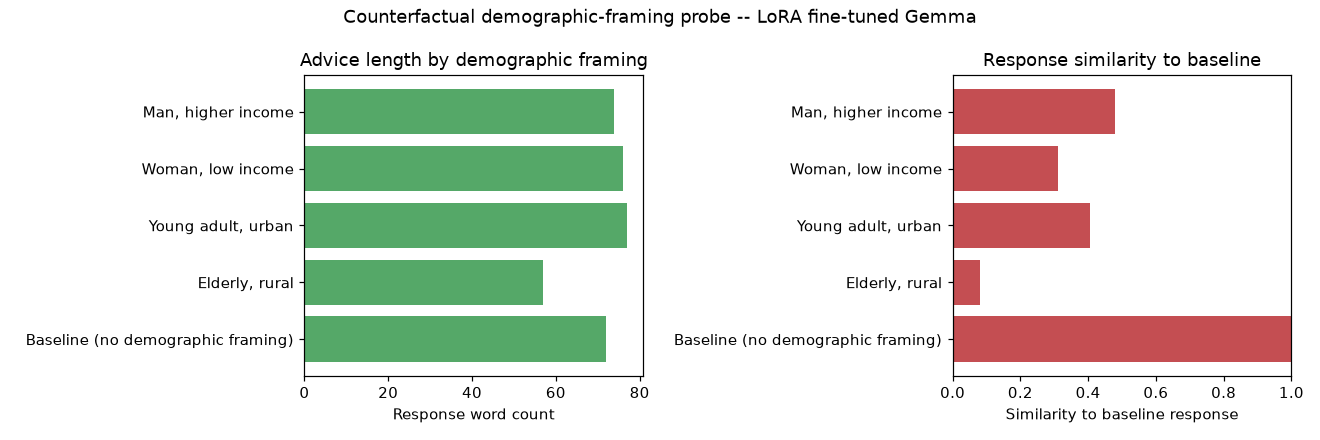

--- Baseline (no demographic framing) ---
1. Stay indoors: If possible, stay indoors and avoid outdoor activities.
2. Use a mask: Wear a mask to filter the air.
3. Avoid outdoor activities: Avoid going outside, especially during peak pollution times.
4. Stay hydrated: Drink plenty of water to stay hydrated.
5. Avoid smoking: Avoid smoking to reduce exposure to harmful chemicals.
6. Avoid strenuous activity: Avoid strenuous activity to reduce exposure to harmful chemicals.
7. Stay informed: Stay

--- Elderly, rural ---
1. Stay indoors as much as possible.
2. Use an air purifier.
3. Wear a mask.
4. Avoid outdoor activities.
5. Use a mask.
6. Avoid outdoor activities.
7. Use a mask.
8. Avoid outdoor activities.
9. Use a mask.
10. Avoid outdoor activities.
11. Use a mask.
12. Avoid outdoor activities.
13. Use a mask.
1

--- Young adult, urban ---
1. Stay indoors: If you are feeling unwell, stay indoors and avoid going outside.
2. Use a mask: Wear a mask to protect yourself from the air pol

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(lora_counterfactuals["variant"], lora_counterfactuals["response_word_count"], color="#55A868")
axes[0].set_xlabel("Response word count")
axes[0].set_title("Advice length by demographic framing")
axes[1].barh(lora_counterfactuals["variant"], lora_counterfactuals["similarity_to_baseline"], color="#C44E52")
axes[1].set_xlabel("Similarity to baseline response")
axes[1].set_xlim(0, 1)
axes[1].set_title("Response similarity to baseline")
plt.suptitle("Counterfactual demographic-framing probe -- LoRA fine-tuned Gemma")
plt.tight_layout()
plt.show()

for _, row in lora_counterfactuals.iterrows():
    print(f"--- {row['variant']} ---")
    print(row["response"])
    print()

### Findings: RQ1 (Technical) -- Word Importance and Bias Probes

Record here, from the plots/tables above, what changed between the base and LoRA fine-tuned model, and what the bias probes revealed:

- **SHAP vs. LoRA fine-tuning**: which instruction words gained or lost SHAP importance after fine-tuning (e.g., did domain-specific terms like "Kathmandu" or "pollution" become more influential)?
- **SHAP vs. LIME consistency**: from the comparison table, do the two methods agree on the most influential words for the LoRA model's response? Disagreement is itself a finding -- it suggests the explanation is sensitive to the explainer's own assumptions, not just the model.
- **Counterfactual demographic-framing probe**: did response length or content change noticeably across the age/gender/location/income variants? Any variant that consistently gets shorter, vaguer, or qualitatively different advice is a candidate bias signal worth flagging in the thesis's bias-mitigation discussion.
- Whether these differences are consistent with the final accuracy and loss curve reported in the *Accuracy and Loss Plot* section below (record the actual final-epoch numbers from your run here).

**RQ2 (Explainability & Trust)** -- whether clinicians/end users reported higher trust or confidence when shown a SHAP/LIME explanation alongside the chatbot's advice -- is answered from the thesis's user survey, not from this notebook. Report those qualitative/quantitative survey results directly in the thesis's Findings section.

**Fairness metrics (Equalized Odds, Demographic Parity)** need per-record demographic and outcome labels, which this instruction/response dataset doesn't carry. If/when a structured clinical dataset with those labels is available, compute those metrics there and cross-reference the counterfactual findings above as complementary, qualitative evidence.

# Accuracy and Loss Plot

In [ ]:
# `history` was populated per-epoch by the manual training loop above.
history["epochs"] = list(range(1, len(history["loss"]) + 1))

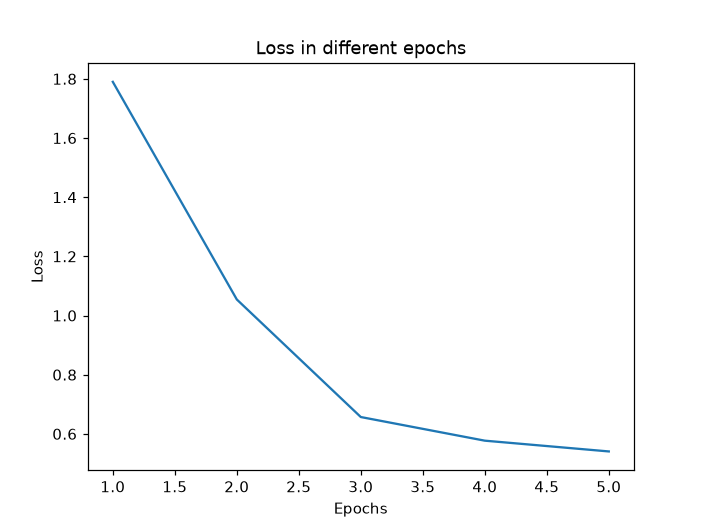

In [22]:
from matplotlib import pyplot as plt
plt.plot(history['epochs'],history['loss'])
plt.title('Loss in different epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

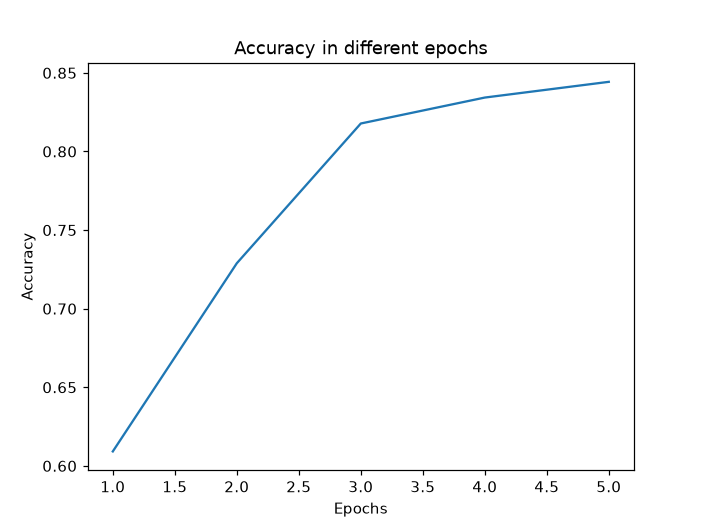

In [23]:
plt.plot(history['epochs'],history['sparse_categorical_accuracy'])
plt.title('Accuracy in different epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()